In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

DRIVE_DIR  = "/content/drive/MyDrive/stress_hydrique_sentinel2"
DATA_PROC  = f"{DRIVE_DIR}/data/processed/"
DATA_VIZ   = f"{DRIVE_DIR}/data/visualisations/"

# Charger le dataset final
df = pd.read_csv(f"{DATA_PROC}dataset_ml_final.csv")
df["date"] = pd.to_datetime(df["date"])

print("Dataset chargé !")
print(f"   Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"   Période    : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\n   Colonnes disponibles :")
for i, col in enumerate(df.columns):
    print(f"   {i+1:2d}. {col}")

Mounted at /content/drive
Dataset chargé !
   Dimensions : 1811 lignes × 41 colonnes
   Période    : 2020-01-02 → 2024-12-16

   Colonnes disponibles :
    1. date
    2. annee
    3. mois
    4. B2
    5. B3
    6. B4
    7. B5
    8. B6
    9. B7
   10. B8
   11. B8A
   12. B11
   13. B12
   14. NDVI
   15. NDWI
   16. EVI
   17. SAVI
   18. NDRE
   19. MSI
   20. LAI
   21. CWSI
   22. CRI
   23. temp_max
   24. temp_min
   25. temp_moy
   26. precipitation
   27. ETo
   28. ETP_Hargreaves
   29. vent_max
   30. rayonnement
   31. deficit_hydrique
   32. SPI_30j
   33. SPI_90j
   34. anomalie_precip
   35. anomalie_precip_cum
   36. deficit_cum_30j
   37. HSI_cum_30j
   38. stress_thermique
   39. amplitude_thermique
   40. label_stress
   41. label_nom


In [2]:
# ── Description de chaque colonne
description = {
    # Temporel
    "date":               ("Temporel",    "Date journalière"),
    "annee":              ("Temporel",    "Année (2020–2024)"),
    "mois":               ("Temporel",    "Mois (1–12)"),
    # Bandes spectrales
    "B2":                 ("Bande S2",    "Bleu (490nm) — diffusion atmosphérique"),
    "B3":                 ("Bande S2",    "Vert (560nm) — réflectance végétation"),
    "B4":                 ("Bande S2",    "Rouge (665nm) — absorption chlorophylle"),
    "B5":                 ("Bande S2",    "Red Edge 1 (705nm) — sensible au stress"),
    "B6":                 ("Bande S2",    "Red Edge 2 (740nm)"),
    "B7":                 ("Bande S2",    "Red Edge 3 (783nm)"),
    "B8":                 ("Bande S2",    "NIR (842nm) — réflectance feuilles saines"),
    "B8A":                ("Bande S2",    "Red Edge 4 (865nm) — NIR étroit"),
    "B11":                ("Bande S2",    "SWIR1 (1610nm) — eau dans végétation"),
    "B12":                ("Bande S2",    "SWIR2 (2190nm) — eau et minéraux sol"),
    # Indices spectraux
    "NDVI":               ("Indice",      "Santé végétation | Seuil stress < 0.30"),
    "NDWI":               ("Indice",      "Eau feuilles | Seuil stress < -0.30"),
    "EVI":                ("Indice",      "Végétation robuste (redondant NDVI)"),
    "SAVI":               ("Indice",      "Végétation sol aride (redondant NDVI)"),
    "NDRE":               ("Indice",      "Détection précoce stress Red Edge"),
    "MSI":                ("Indice",      "Stress SWIR direct | Seuil stress > 1.0"),
    "LAI":                ("Indice",      "Surface foliaire m²/m² | Stress < 1.0"),
    "CWSI":               ("Indice",      "Stress culture 0→1 (redondant NDVI)"),
    "CRI":                ("Indice",      "Caroténoïdes stress | Seuil > 5"),
    # Météo de base
    "temp_max":           ("Météo base",  "Température maximale journalière (°C)"),
    "temp_min":           ("Météo base",  "Température minimale journalière (°C)"),
    "temp_moy":           ("Météo base",  "Température moyenne journalière (°C)"),
    "precipitation":      ("Météo base",  "Précipitations journalières (mm)"),
    "ETo":                ("Météo base",  "Évapotranspiration FAO-56 (mm/jour)"),
    "ETP_Hargreaves":     ("Météo base",  "ETP méthode Hargreaves (mm/jour)"),
    "vent_max":           ("Météo base",  "Vitesse maximale vent (km/h)"),
    "rayonnement":        ("Météo base",  "Rayonnement solaire (MJ/m²/jour)"),
    "deficit_hydrique":   ("Météo base",  "Déficit P-ETo journalier (mm/jour)"),
    # Météo avancée
    "SPI_30j":            ("Météo avancée","Sécheresse standardisée 30j | < -1 = sécheresse"),
    "SPI_90j":            ("Météo avancée","Sécheresse standardisée 90j | < -1 = sécheresse"),
    "anomalie_precip":    ("Météo avancée","Écart précip vs normale mensuelle (mm)"),
    "anomalie_precip_cum":("Météo avancée","Anomalie précip cumulée depuis 2020 (mm)"),
    "deficit_cum_30j":    ("Météo avancée","Déficit hydrique cumulé 30j (mm)"),
    "HSI_cum_30j":        ("Météo avancée","Jours chaleur extrême (T>35°C) / 30j"),
    "stress_thermique":   ("Météo avancée","Jour de chaleur extrême : 0 ou 1"),
    "amplitude_thermique":("Météo avancée","Tmax - Tmin journalier (°C)"),
    # Labels
    "label_stress":       ("Label ML",    "Niveau stress 0=sain 1=risque 2=modéré 3=sévère"),
    "label_nom":          ("Label ML",    "Nom du label en texte"),
}

# Affichage tableau
print("=" * 90)
print(f"{'#':3s}  {'Colonne':25s}  {'Groupe':15s}  {'Description'}")
print("=" * 90)

groupes_colors = {
    "Temporel":      "🕐",
    "Bande S2":      "🛰️",
    "Indice":        "📊",
    "Météo base":    "🌤️",
    "Météo avancée": "🌧️",
    "Label ML":      "🏷️",
}

for i, col in enumerate(df.columns):
    if col in description:
        groupe, desc = description[col]
        emoji = groupes_colors.get(groupe, "")
        print(f"{i+1:3d}. {col:25s}  {emoji} {groupe:13s}  {desc}")

print("=" * 90)
print(f"\n📋 Résumé par groupe :")
from collections import Counter
groupes = [description[c][0] for c in df.columns if c in description]
for g, n in Counter(groupes).items():
    print(f"   {groupes_colors.get(g,'')} {g:20s} : {n} colonnes")

#    Colonne                    Groupe           Description
  1. date                       🕐 Temporel       Date journalière
  2. annee                      🕐 Temporel       Année (2020–2024)
  3. mois                       🕐 Temporel       Mois (1–12)
  4. B2                         🛰️ Bande S2       Bleu (490nm) — diffusion atmosphérique
  5. B3                         🛰️ Bande S2       Vert (560nm) — réflectance végétation
  6. B4                         🛰️ Bande S2       Rouge (665nm) — absorption chlorophylle
  7. B5                         🛰️ Bande S2       Red Edge 1 (705nm) — sensible au stress
  8. B6                         🛰️ Bande S2       Red Edge 2 (740nm)
  9. B7                         🛰️ Bande S2       Red Edge 3 (783nm)
 10. B8                         🛰️ Bande S2       NIR (842nm) — réflectance feuilles saines
 11. B8A                        🛰️ Bande S2       Red Edge 4 (865nm) — NIR étroit
 12. B11                        🛰️ Bande S2       SWIR1 (1610nm) — eau dans 

In [7]:
# ── 1. Aperçu du dataset
print("=== APERÇU DU DATASET ===")
print(df.head(10).to_string())

print(f"\n=== DIMENSIONS ===")
print(f"Lignes   : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")

print(f"\n=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("Aucune valeur manquante ")
else:
    print(missing)

print(f"\n=== TYPES DES COLONNES ===")
print(df.dtypes)

=== APERÇU DU DATASET ===
        date  annee  mois        B2        B3        B4        B5        B6        B7        B8       B8A       B11       B12      NDVI      NDWI       EVI      SAVI      NDRE       MSI       LAI      CWSI        CRI  temp_max  temp_min  temp_moy  precipitation   ETo  ETP_Hargreaves  vent_max  rayonnement  deficit_hydrique  SPI_30j  SPI_90j  anomalie_precip  anomalie_precip_cum  deficit_cum_30j  HSI_cum_30j  stress_thermique  amplitude_thermique  label_stress      label_nom
0 2020-01-02   2020     1  0.420386  0.410577  0.399318  0.441918  0.472472  0.480750  0.483173  0.476578  0.429591  0.401265  0.095021 -0.081226  0.288685  0.090983  0.037736  0.889104  0.000000  1.000000  -0.056832      19.3       7.2     13.25            0.0  1.57        1.061180       9.7        10.47             -1.57      NaN      NaN         -1.59871            -3.197419              NaN          NaN                 0                 12.1             1         Risque
1 2020-01-03   2

In [8]:
print("=== STATISTIQUES GÉNÉRALES ===")
print(df.describe().round(3).to_string())

=== STATISTIQUES GÉNÉRALES ===
                      date     annee      mois        B2        B3        B4        B5        B6        B7        B8       B8A       B11       B12      NDVI      NDWI       EVI      SAVI      NDRE       MSI       LAI      CWSI       CRI  temp_max  temp_min  temp_moy  precipitation       ETo  ETP_Hargreaves  vent_max  rayonnement  deficit_hydrique   SPI_30j   SPI_90j  anomalie_precip  anomalie_precip_cum  deficit_cum_30j  HSI_cum_30j  stress_thermique  amplitude_thermique  label_stress
count                 1811  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000  1811.000       1811.000  1811.000        1811.000  1811.000     1811.000          1811.000  1798.000  1768.000         1811.000             1811.000         1798.000     1798.000          1811.000             1811.000    

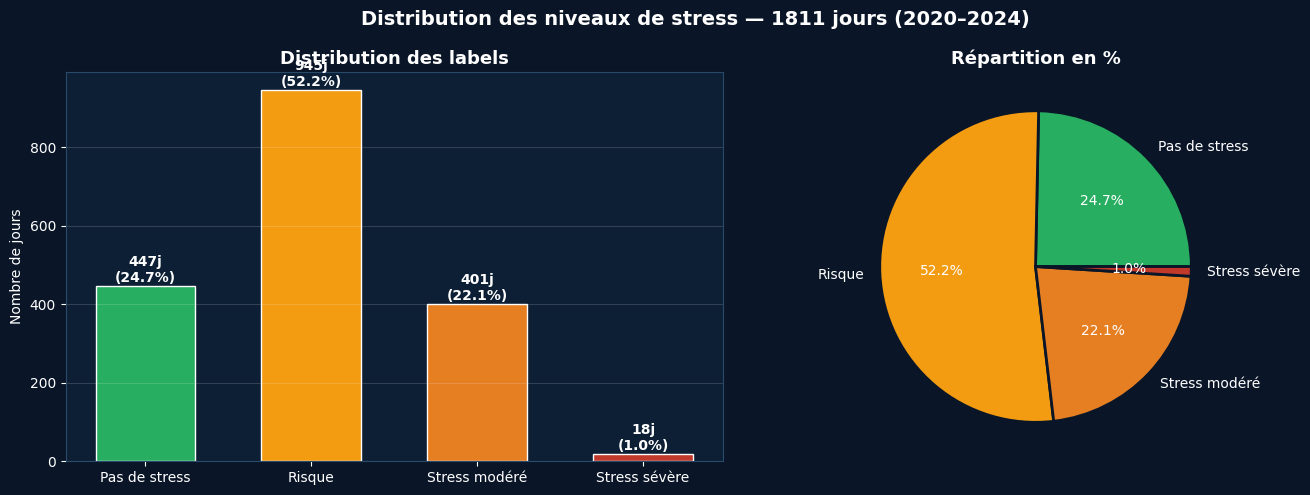

 Figure sauvegardée


In [9]:
# Figure 1 : Distribution des labels en %
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0A1628")
for ax in axes:
    ax.set_facecolor("#0D1F35")

couleurs = {0:"#27AE60",1:"#F39C12",2:"#E67E22",3:"#C0392B"}
noms     = {0:"Pas de stress",1:"Risque",
            2:"Stress modéré",3:"Stress sévère"}

# Barres
counts = df["label_stress"].value_counts().sort_index()
bars = axes[0].bar([noms[i] for i in counts.index],
                    counts.values,
                    color=[couleurs[i] for i in counts.index],
                    edgecolor="white", width=0.6)
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+10,
                 f"{val}j\n({pct:.1f}%)",
                 ha="center", color="white",
                 fontsize=10, fontweight="bold")
axes[0].set_title("Distribution des labels", color="white",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Nombre de jours", color="white")
axes[0].tick_params(colors="white")
axes[0].grid(axis="y")

# Camembert
axes[1].pie(counts.values,
            labels=[noms[i] for i in counts.index],
            colors=[couleurs[i] for i in counts.index],
            autopct="%1.1f%%",
            textprops={"color":"white", "fontsize":10},
            wedgeprops={"edgecolor":"#0A1628","linewidth":2})
axes[1].set_title("Répartition en %", color="white",
                  fontsize=13, fontweight="bold")

plt.suptitle("Distribution des niveaux de stress — 1811 jours (2020–2024)",
             color="white", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{DATA_VIZ}EDA_distribution_labels.png",
            dpi=150, bbox_inches="tight", facecolor="#0A1628")
plt.show()
print(" Figure sauvegardée")

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score)
import numpy as np

# ── Features sélectionnées
features = ["NDVI","NDWI","MSI","NDRE","CRI","LAI",
            "SPI_30j","deficit_cum_30j","HSI_cum_30j",
            "temp_max","ETo","amplitude_thermique"]

X = df[features].fillna(0)
y = df["label_stress"]

# ── Split temporel (pas aléatoire !)
# On entraîne sur 2020-2023, on teste sur 2024
mask_train = df["annee"] < 2024
mask_test  = df["annee"] == 2024

X_train = X[mask_train]
X_test  = X[mask_test]
y_train = y[mask_train]
y_test  = y[mask_test]

# ── Normalisation
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(" Données prêtes !")
print(f"\n   Entraînement : {len(y_train)} jours (2020–2023)")
print(f"   Test         : {len(y_test)}  jours (2024)")
print(f"   Features     : {len(features)}")
print(f"\n   Distribution train :")
for label, nom in noms.items():
    n = (y_train == label).sum()
    print(f"   Label {label} — {nom:15s} : {n} jours")
print(f"\n   Distribution test :")
for label, nom in noms.items():
    n = (y_test == label).sum()
    print(f"   Label {label} — {nom:15s} : {n} jours")

 Données prêtes !

   Entraînement : 1460 jours (2020–2023)
   Test         : 351  jours (2024)
   Features     : 12

   Distribution train :
   Label 0 — Pas de stress   : 348 jours
   Label 1 — Risque          : 799 jours
   Label 2 — Stress modéré   : 297 jours
   Label 3 — Stress sévère   : 16 jours

   Distribution test :
   Label 0 — Pas de stress   : 99 jours
   Label 1 — Risque          : 146 jours
   Label 2 — Stress modéré   : 104 jours
   Label 3 — Stress sévère   : 2 jours


In [11]:
# ── Entraînement Random Forest
print(" Entraînement Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,    # 200 arbres
    max_depth=15,        # profondeur max
    min_samples_leaf=5,  # minimum 5 jours par feuille
    class_weight="balanced",  # compense le déséquilibre des classes
    random_state=42,
    n_jobs=-1            # utilise tous les CPU
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Modèle entraîné !")

# ── Résultats
acc = accuracy_score(y_test, y_pred)
print(f"\n=== RÉSULTATS ===")
print(f"Accuracy globale : {acc*100:.1f}%")

print(f"\n=== RAPPORT DÉTAILLÉ ===")
print(classification_report(y_test, y_pred,
      target_names=[noms[i] for i in range(4)]))

 Entraînement Random Forest...
Modèle entraîné !

=== RÉSULTATS ===
Accuracy globale : 91.2%

=== RAPPORT DÉTAILLÉ ===
               precision    recall  f1-score   support

Pas de stress       0.91      0.95      0.93        99
       Risque       0.89      0.91      0.90       146
Stress modéré       0.96      0.88      0.91       104
Stress sévère       0.50      1.00      0.67         2

     accuracy                           0.91       351
    macro avg       0.82      0.93      0.85       351
 weighted avg       0.92      0.91      0.91       351



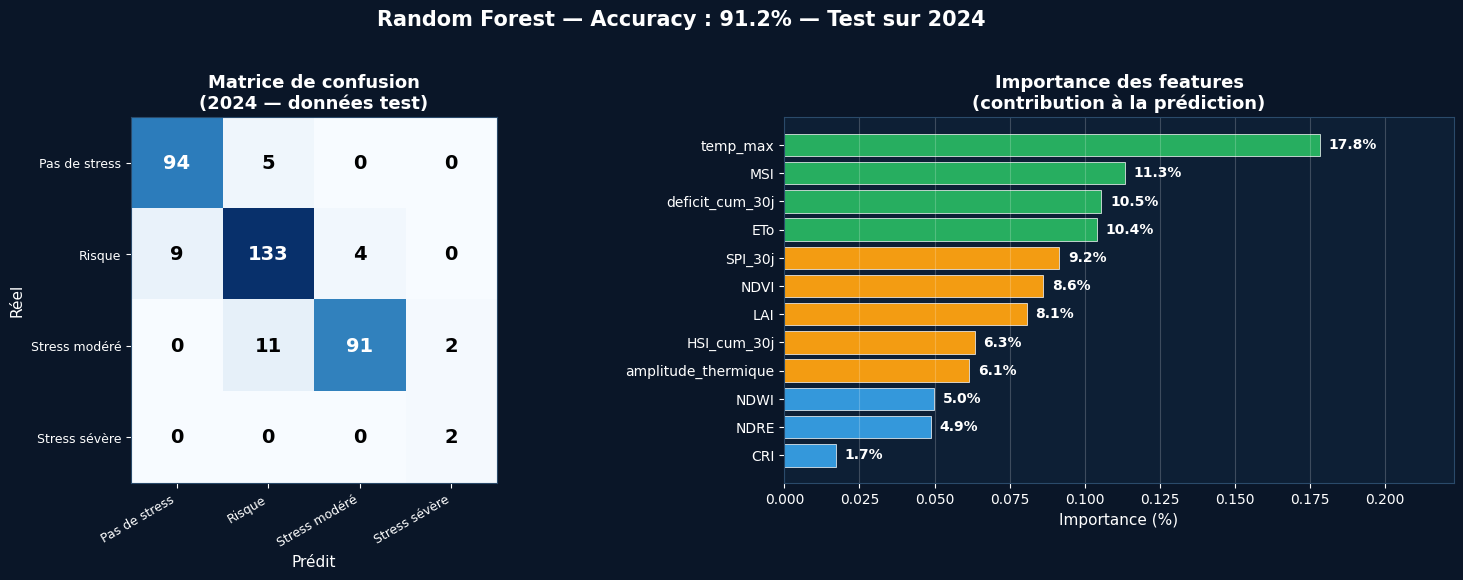

 Figure sauvegardée !

=== IMPORTANCE DES FEATURES ===
   temp_max                  : 17.8%
   MSI                       : 11.3%
   deficit_cum_30j           : 10.5%
   ETo                       : 10.4%
   SPI_30j                   : 9.2%
   NDVI                      : 8.6%
   LAI                       : 8.1%
   HSI_cum_30j               : 6.3%
   amplitude_thermique       : 6.1%
   NDWI                      : 5.0%
   NDRE                      : 4.9%
   CRI                       : 1.7%


In [12]:
# ── Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0A1628")
for ax in axes:
    ax.set_facecolor("#0D1F35")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap="Blues")

labels_noms = [noms[i] for i in range(4)]
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(labels_noms, rotation=30,
                         ha="right", color="white", fontsize=9)
axes[0].set_yticklabels(labels_noms, color="white", fontsize=9)

for i in range(4):
    for j in range(4):
        val = cm[i, j]
        col = "white" if val > cm.max()/2 else "black"
        axes[0].text(j, i, str(val),
                     ha="center", va="center",
                     fontsize=14, fontweight="bold", color=col)

axes[0].set_xlabel("Prédit", color="white", fontsize=11)
axes[0].set_ylabel("Réel", color="white", fontsize=11)
axes[0].set_title("Matrice de confusion\n(2024 — données test)",
                  color="white", fontsize=13, fontweight="bold")

# Importance des features
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1]
feat_sorted = [features[i] for i in indices]
imp_sorted  = importances[indices]

colors_feat = ["#27AE60" if imp > 0.10 else
               "#F39C12" if imp > 0.05 else
               "#3498DB" for imp in imp_sorted]

bars = axes[1].barh(feat_sorted[::-1], imp_sorted[::-1],
                    color=colors_feat[::-1],
                    edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, imp_sorted[::-1]):
    axes[1].text(val + 0.003, bar.get_y()+bar.get_height()/2,
                 f"{val*100:.1f}%", va="center",
                 color="white", fontsize=10, fontweight="bold")

axes[1].set_title("Importance des features\n(contribution à la prédiction)",
                  color="white", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Importance (%)", color="white", fontsize=11)
axes[1].tick_params(colors="white")
axes[1].grid(True, axis="x", alpha=0.2)
axes[1].set_xlim(0, max(imp_sorted)*1.25)

fig.suptitle(f"Random Forest — Accuracy : {acc*100:.1f}% — Test sur 2024",
             color="white", fontsize=15, fontweight="bold")

plt.tight_layout(pad=2.0)
plt.savefig(f"{DATA_VIZ}RF_resultats.png",
            dpi=150, bbox_inches="tight", facecolor="#0A1628")
plt.show()
print(" Figure sauvegardée !")

# ── Résumé importance
print("\n=== IMPORTANCE DES FEATURES ===")
for i in indices:
    print(f"   {features[i]:25s} : {importances[i]*100:.1f}%")

In [13]:
import pickle
import os

# ── Sauvegarder le modèle
os.makedirs(f"{DRIVE_DIR}/models", exist_ok=True)

model_path  = f"{DRIVE_DIR}/models/random_forest_v1.pkl"
scaler_path = f"{DRIVE_DIR}/models/scaler_v1.pkl"

with open(model_path, "wb") as f:
    pickle.dump(rf, f)

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print(" Modèle sauvegardé !")
print(f"   Modèle : {model_path}")
print(f"   Scaler : {scaler_path}")



 Modèle sauvegardé !
   Modèle : /content/drive/MyDrive/stress_hydrique_sentinel2/models/random_forest_v1.pkl
   Scaler : /content/drive/MyDrive/stress_hydrique_sentinel2/models/scaler_v1.pkl
